# Domain presets on real data

A preset shines when the data matches its domain. This notebook pairs presets with real fields: a bundled elevation DEM, and **NOAA ERSST v5** sea-surface temperature fetched from the internet (its anomaly too). Every plot is the same one-liner - `imshow(data, style="<preset>")`.

In [1]:
%matplotlib inline
from pathlib import Path
import urllib.request, warnings
import numpy as np
from pyramids.netcdf import NetCDF
from pyramids.dataset import Dataset
from digitalearth.scene import Map
from digitalearth.scene import projections as proj

DATA = Path('../../../examples/data')   # notebook-relative path (docs/examples/presets -> repo root)
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))

# Real climate data, fetched from the internet: NOAA ERSST v5 monthly sea-surface temperature
# (2-degree global grid), via the pydata/xarray-data mirror on GitHub. Cached under the gitignored
# examples/data/global/ so a second run is offline.
CACHE = Path('../../../examples/data/global'); CACHE.mkdir(parents=True, exist_ok=True)
SST_NC = CACHE / 'ersstv5.nc'
if not SST_NC.exists():
    url = 'https://github.com/pydata/xarray-data/raw/master/ersstv5.nc'
    print('downloading ERSST v5 ...')
    SST_NC.write_bytes(urllib.request.urlopen(
        urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}), timeout=180).read())
nc = NetCDF.read_file(str(SST_NC)).get_variable('sst')

def sst_month(band):
    """One month of SST as a pyramids Dataset (the land fill value becomes NaN)."""
    a = nc.read_array(band=band).astype('float32')
    a = np.where(a < -1e30, np.nan, a)
    return Dataset.create_from_array(arr=a, geo=nc.geotransform, epsg=nc.epsg)


## Elevation - a terrain preset on a real DEM

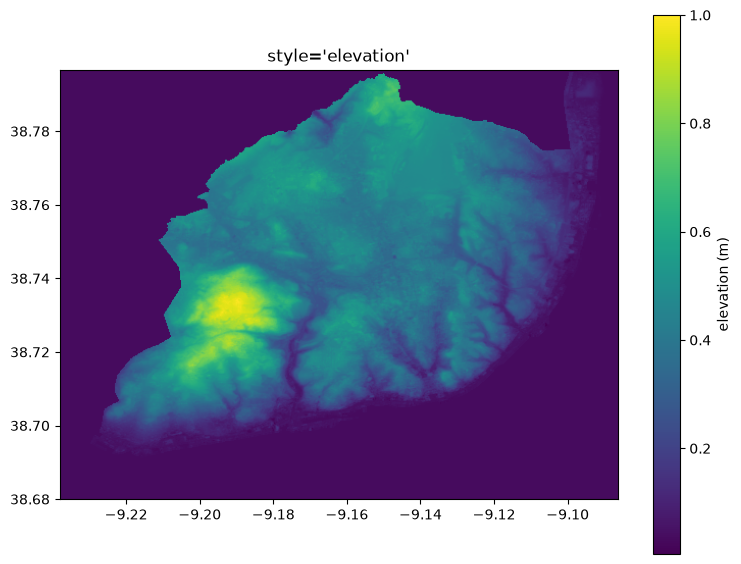

In [2]:
m = Map(crs=dem.epsg, figsize=(9, 7))
m.imshow(dem, style='elevation')
m.colorbar(label='elevation (m)'); m.set_title("style='elevation'"); m.fig;

## Sea-surface temperature - a real ocean field

The most recent month of ERSST v5, styled with the `sea_surface_temperature` preset.

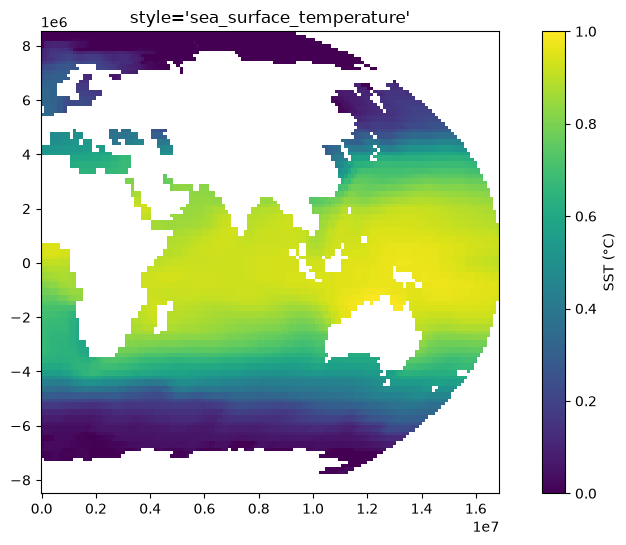

In [3]:
sst = sst_month(nc.band_count - 1)
m = Map(crs=proj.robinson(), figsize=(11, 6))
m.imshow(sst, style='sea_surface_temperature')
m.colorbar(label='SST (\u00b0C)'); m.set_title("style='sea_surface_temperature'"); m.fig;

## Anomaly - a diverging preset on the real record

The most recent month minus the 52-year mean, drawn with the diverging `anomaly` preset centred on zero.

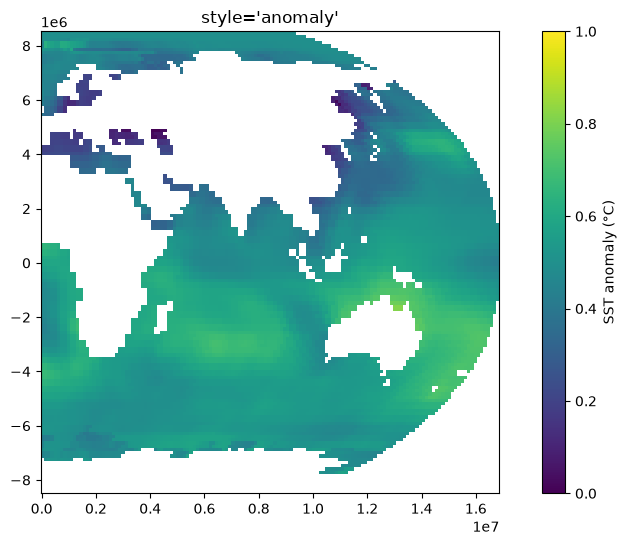

In [4]:
cube = nc.read_array().astype('float32'); cube = np.where(cube < -1e30, np.nan, cube)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    anom = cube[-1] - np.nanmean(cube, axis=0)
m = Map(crs=proj.robinson(), figsize=(11, 6))
m.imshow(Dataset.create_from_array(arr=anom.astype('float32'), geo=nc.geotransform, epsg=nc.epsg), style='anomaly')
m.colorbar(label='SST anomaly (\u00b0C)'); m.set_title("style='anomaly'"); m.fig;

## Precipitation - an illustrative field

A quick synthetic wet field (no bundled global precipitation raster) shows the sequential `precipitation` preset; on real gridded precipitation the call is identical.

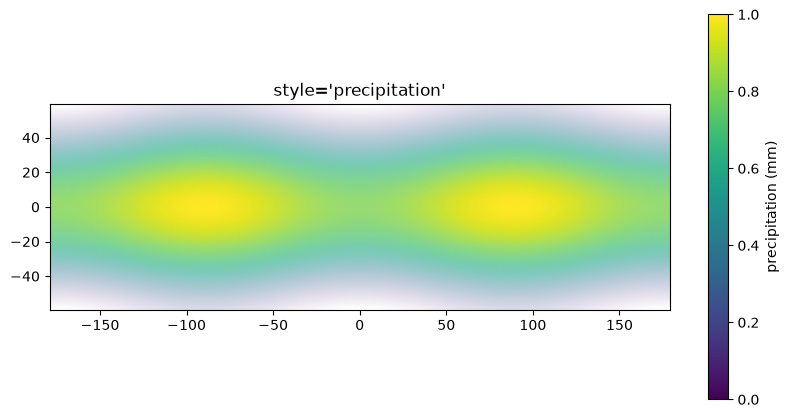

In [5]:
lat = np.linspace(60, -60, 90)[:, None]; lon = np.linspace(-180, 180, 180)[None, :]
precip = np.clip(220 * np.cos(np.deg2rad(lat))**2 + 40 * np.sin(np.deg2rad(lon))**2, 0, None).astype('float32')
pd_ = Dataset.create_from_array(arr=precip, geo=(-180.0, 2.0, 0.0, 60.0, 0.0, -120/90), epsg=4326)
m = Map(crs=4326, figsize=(10, 5))
m.imshow(pd_, style='precipitation')
m.colorbar(label='precipitation (mm)'); m.set_title("style='precipitation'"); m.fig;

The preset only changes the *styling* - the same field renders identically through `imshow`, `contourf` or `pcolormesh`, and the choice of preset is always a single keyword. See `05_globe_and_projections` for the same real data on the globe and across map projections.